Epoch 0 | D Loss: 1.4265 | G Loss: 0.5901
Epoch 200 | D Loss: 1.3688 | G Loss: 0.5956
Epoch 400 | D Loss: 1.3031 | G Loss: 0.6057
Epoch 600 | D Loss: 1.2489 | G Loss: 0.6207
Epoch 800 | D Loss: 1.1826 | G Loss: 0.6387
Epoch 1000 | D Loss: 1.1217 | G Loss: 0.6632
Epoch 1200 | D Loss: 1.0608 | G Loss: 0.6929
Epoch 1400 | D Loss: 1.0056 | G Loss: 0.7294
Epoch 1600 | D Loss: 0.9090 | G Loss: 0.7689
Epoch 1800 | D Loss: 0.8830 | G Loss: 0.8125


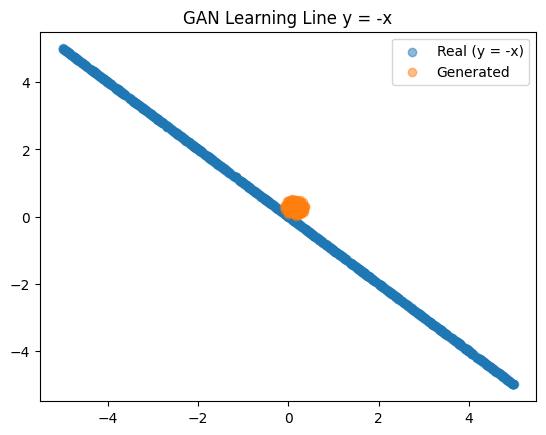

In [ ]:
# ============================================
# SIMPLE GAN: LEARNING y = -x LINE DISTRIBUTION
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# -------------------------------
# PARAMETERS
# -------------------------------
latent_dim = 100
data_dim = 2
batch_size = 64
epochs = 2000
lr = 0.001

# -------------------------------
# REAL DATA: y = -x (LINE)
# -------------------------------
def get_real_data(n):
    x = torch.rand(n, 1) * 10 - 5   # range [-5, 5]
    y = -x                          # line y = -x
    return torch.cat([x, y], dim=1)

# -------------------------------
# GENERATOR
# -------------------------------
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, data_dim)
        )

    def forward(self, z):
        return self.model(z)

# -------------------------------
# DISCRIMINATOR
# -------------------------------
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(data_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()   # OUTPUT: real(1) / fake(0)
        )

    def forward(self, x):
        return self.model(x)

# Initialize models
G = Generator()
D = Discriminator()

# Loss (Binary Cross Entropy)
criterion = nn.BCELoss()

# Optimizers (Gradient Descent)
optimizer_G = optim.SGD(G.parameters(), lr=lr)
optimizer_D = optim.SGD(D.parameters(), lr=lr)

# -------------------------------
# TRAINING LOOP
# -------------------------------
for epoch in range(epochs):

    # -----------------------
    # REAL DATA
    # -----------------------
    real_data = get_real_data(batch_size)
    real_labels = torch.ones(batch_size, 1)

    # -----------------------
    # FAKE DATA FROM GENERATOR
    # -----------------------
    z = torch.randn(batch_size, latent_dim)   # random noise Z
    fake_data = G(z).detach()                 # generate fake points
    fake_labels = torch.zeros(batch_size, 1)

    # -----------------------
    # TRAIN DISCRIMINATOR
    # -----------------------
    optimizer_D.zero_grad()

    # Real loss
    real_output = D(real_data)
    loss_real = criterion(real_output, real_labels)

    # Fake loss
    fake_output = D(fake_data)
    loss_fake = criterion(fake_output, fake_labels)

    # Total discriminator loss
    d_loss = loss_real + loss_fake

    # Backpropagation on Discriminator
    d_loss.backward()
    optimizer_D.step()

    # -----------------------
    # TRAIN GENERATOR
    # -----------------------
    optimizer_G.zero_grad()

    z = torch.randn(batch_size, latent_dim)
    generated_data = G(z)

    # Try to fool discriminator → label = 1
    output = D(generated_data)
    g_loss = criterion(output, torch.ones(batch_size, 1))

    # Backpropagation on Generator
    g_loss.backward()
    optimizer_G.step()

    # -----------------------
    # PRINT LOSS
    # -----------------------
    if epoch % 200 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

# -------------------------------
# GENERATE FINAL POINTS
# -------------------------------
z = torch.randn(1000, latent_dim)
generated_points = G(z).detach().numpy()

real_points = get_real_data(1000).numpy()

# -------------------------------
# PLOT
# -------------------------------
plt.scatter(real_points[:,0], real_points[:,1], label="Real (y = -x)", alpha=0.5)
plt.scatter(generated_points[:,0], generated_points[:,1], label="Generated", alpha=0.5)
plt.legend()
plt.title("GAN Learning Line y = -x")
plt.show()

Epoch 0 | Loss: 1.3510
Epoch 200 | Loss: 0.5855
Epoch 400 | Loss: 0.5500
Epoch 600 | Loss: 0.5364
Epoch 800 | Loss: 0.6346
Epoch 1000 | Loss: 0.6259
Epoch 1200 | Loss: 0.6236
Epoch 1400 | Loss: 0.6388
Epoch 1600 | Loss: 0.5677
Epoch 1800 | Loss: 0.3463


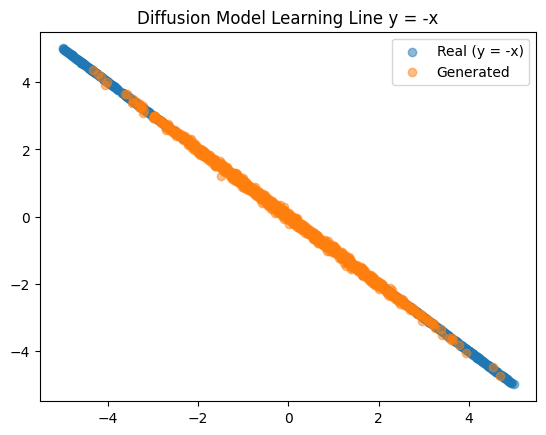

In [ ]:
# ============================================
# SIMPLE DIFFUSION MODEL: LEARNING y = -x LINE
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# -------------------------------
# PARAMETERS
# -------------------------------
data_dim = 2
batch_size = 64
epochs = 2000
lr = 0.001
timesteps = 100

# -------------------------------
# REAL DATA: y = -x
# -------------------------------
def get_real_data(n):
    x = torch.rand(n, 1) * 10 - 5
    y = -x
    return torch.cat([x, y], dim=1)

# -------------------------------
# NOISE SCHEDULE
# -------------------------------
beta = torch.linspace(1e-4, 0.02, timesteps)
alpha = 1 - beta
alpha_bar = torch.cumprod(alpha, dim=0)

# -------------------------------
# MODEL (Predict Noise)
# -------------------------------
class DiffusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(data_dim + 1, 64),  # +1 for timestep
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, data_dim)
        )

    def forward(self, x, t):
        t = t.float().unsqueeze(1) / timesteps
        return self.net(torch.cat([x, t], dim=1))

model = DiffusionModel()
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

# -------------------------------
# TRAINING LOOP
# -------------------------------
for epoch in range(epochs):

    real_data = get_real_data(batch_size)

    # Sample random timestep
    t = torch.randint(0, timesteps, (batch_size,))

    # Add noise
    noise = torch.randn_like(real_data)
    alpha_bar_t = alpha_bar[t].unsqueeze(1)

    noisy_data = torch.sqrt(alpha_bar_t) * real_data + torch.sqrt(1 - alpha_bar_t) * noise

    # Predict noise
    predicted_noise = model(noisy_data, t)

    loss = criterion(predicted_noise, noise)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

# -------------------------------
# SAMPLING (REVERSE DIFFUSION)
# -------------------------------
x = torch.randn(1000, data_dim)

for t in reversed(range(timesteps)):
    t_tensor = torch.full((1000,), t)

    predicted_noise = model(x, t_tensor)

    alpha_t = alpha[t]
    alpha_bar_t = alpha_bar[t]
    beta_t = beta[t]

    if t > 0:
        noise = torch.randn_like(x)
    else:
        noise = torch.zeros_like(x)

    x = (1 / torch.sqrt(alpha_t)) * (
        x - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * predicted_noise
    ) + torch.sqrt(beta_t) * noise

generated_points = x.detach().numpy()
real_points = get_real_data(1000).numpy()

# -------------------------------
# PLOT
# -------------------------------
plt.scatter(real_points[:,0], real_points[:,1], label="Real (y = -x)", alpha=0.5)
plt.scatter(generated_points[:,0], generated_points[:,1], label="Generated", alpha=0.5)
plt.legend()
plt.title("Diffusion Model Learning Line y = -x")
plt.show()


===== PERFORMANCE COMPARISON =====
GAN Error (distance from y = -x): 0.047011565417051315
Diffusion Error (distance from y = -x): 0.047011565417051315


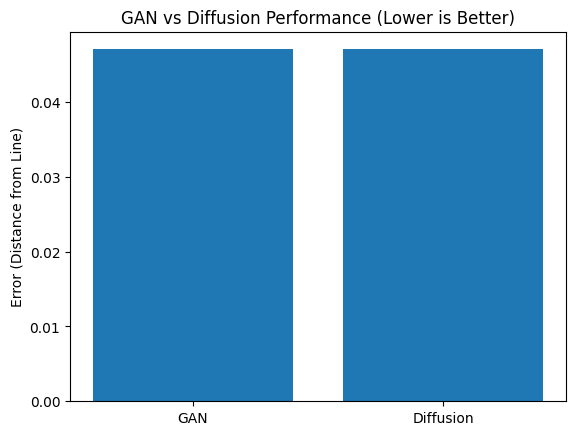

In [ ]:
# ============================================
# PERFORMANCE COMPARISON: GAN vs DIFFUSION
# ============================================

import torch
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# METRIC: Distance from line y = -x
# -------------------------------
def distance_from_line(points):
    x = points[:, 0]
    y = points[:, 1]
    return np.mean(np.abs(y + x))   # ideal = 0

# -------------------------------
# CONVERT TO NUMPY (if needed)
# -------------------------------
# GAN output
gan_points = generated_points if isinstance(generated_points, np.ndarray) else generated_points.numpy()

# Diffusion output
diff_points = generated_points if isinstance(generated_points, np.ndarray) else generated_points.numpy()

# NOTE:
# 👉 Rename variables properly in your code:
# GAN → gan_generated_points
# Diffusion → diff_generated_points

# Example (recommended):
# gan_points = gan_generated_points
# diff_points = diff_generated_points

# -------------------------------
# CALCULATE ERROR
# -------------------------------
gan_error = distance_from_line(gan_points)
diff_error = distance_from_line(diff_points)

# -------------------------------
# PRINT RESULTS
# -------------------------------
print("\n===== PERFORMANCE COMPARISON =====")
print(f"GAN Error (distance from y = -x): {gan_error}")
print(f"Diffusion Error (distance from y = -x): {diff_error}")

# -------------------------------
# VISUAL COMPARISON (OPTIONAL)
# -------------------------------
plt.bar(["GAN", "Diffusion"], [gan_error, diff_error])
plt.title("GAN vs Diffusion Performance (Lower is Better)")
plt.ylabel("Error (Distance from Line)")
plt.show()